# Step-by-step Pipeline Debug Notebook (v2)

This notebook breaks the one-line pipeline ("python -m src.pipeline --mode live --notebook 02") into **inspectable stages**.

It is designed for report-writing and debugging: you can see what data looks like after each step, and you can visualize intermediate outputs before moving to the next stage.

**Notes**
- This notebook uses the same code modules under `src/` as the pipeline.
- In `live` mode it downloads data via `yfinance`, so runtime depends on network and Yahoo stability.
- You can start with a small scope (one horizon, one feature set, one model) and then expand.


In [1]:
# If running in Jupyter: ensure plots show inline
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Project imports
from src.config import AppConfig
from src.data_loader import load_data
from src.features import build_feature_frame, feature_columns_for_set
from src.labels import add_forward_labels
from src.leakage import leakage_guard
from src.splits import time_split
from src.models import build_models, choose_threshold
from src.evaluation import compute_ml_metrics, compute_signal_metrics, decile_return_table
from src.backtest import run_benchmark_buy_hold, run_top_k_execution_backtest, relative_summary


## 1) Configuration

We load the default `AppConfig()` and optionally narrow the scope for faster iteration.

In [2]:
config = AppConfig(universe="SPY100+QQQ100")
config

AppConfig(project_root=WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2'), data_dir=WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/data'), output_dir=WindowsPath('C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2/outputs'), random_seed=42, universe='SPY100+QQQ100', universe_cache=True, universe_allow_download=True, tickers=['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'GOOG', 'META', 'TSLA', 'AVGO', 'BRK-B', 'JPM', 'JNJ', 'XOM', 'V', 'MA', 'PG', 'UNH', 'HD', 'CVX', 'MRK', 'LLY', 'ABBV', 'PEP', 'KO', 'COST', 'WMT', 'MCD', 'NKE', 'CRM', 'ADBE', 'NFLX', 'ORCL', 'CSCO', 'INTC', 'AMD', 'QCOM', 'TXN', 'AMAT', 'LRCX', 'KLAC', 'MU', 'ASML', 'SNPS', 'CDNS', 'NOW', 'INTU', 'ISRG', 'AMGN', 'GILD', 'REGN', 'VRTX', 'BKNG', 'ABNB', 'PANW', 'CRWD', 'ZS', 'FTNT', 'MDB', 'TEAM', 'DDOG', 'SNOW', 'PYPL', 'SQ', 'SHOP', 'UBER', 'LYFT', 'SPOT', 'RBLX', 'EA', 'TTWO', 'CMCSA', 'TMUS', 'T', 'VZ', 'DIS', 'CHTR', 'TMO', 'DHR', 'ABT', 'MDT', 'BSX', 'SYK', 'ZTS', '

In [3]:
# OPTIONAL: start small for debugging (uncomment to use)
# config.horizons = [3]
# config.feature_sets = {"F5_full_finance_no_fundamental": config.feature_sets["F5_full_finance_no_fundamental"]}
# config.tickers = config.tickers[:10]
# config.top_k = 5
# config.transaction_cost_bps = 10

print('Tickers:', len(config.tickers))
print('Horizons:', config.horizons)
print('Feature sets:', list(config.feature_sets.keys()))
print('Top K:', config.top_k, 'Cost (bps):', config.transaction_cost_bps)
print('Output dir:', config.output_dir)

Tickers: 164
Horizons: [1, 3]
Feature sets: ['F1_momentum', 'F2_momentum_reversal', 'F3_plus_risk_liquidity', 'F4_plus_cross_sectional', 'F5_full_finance_no_fundamental']
Top K: 5 Cost (bps): 10.0
Output dir: C:\Users\user\Downloads\Moltbot\HKU-FYP\fyp_finance_ml_v2\outputs


## 2) Load raw data (prices, benchmark, macro, fundamentals)

This step calls `load_data(config, mode='live')` and returns:
- `prices`: panel of daily OHLCV for all tickers
- `benchmark`: SPY OHLCV
- `macro`, `fundamentals`: optional auxiliary tables (if enabled/available)

In [4]:
mode = 'live'  # change to 'synthetic' for offline testing
prices, benchmark, macro, fundamentals = load_data(config, mode=mode)

# Filter to configured universe (same as pipeline)
prices = prices.loc[prices['ticker'].isin(config.tickers)].copy()

print('prices:', prices.shape)
print('benchmark:', benchmark.shape)
print('macro:', None if macro is None else macro.shape)
print('fundamentals:', None if fundamentals is None else fundamentals.shape)

prices.head()

prices: (412296, 8)
benchmark: (2514, 2)
macro: (2514, 5)
fundamentals: (0, 0)


,date,ticker,open,high,low,close,adj_close,volume
0,2016-01-04,AAPL,25.652500,26.342501,25.500000,26.337500,23.730946,270597600.0
1,2016-01-05,AAPL,26.437500,26.462500,25.602501,25.677500,23.136265,223164000.0
2,2016-01-06,AAPL,25.139999,25.592501,24.967501,25.174999,22.683498,273829600.0
3,2016-01-07,AAPL,24.670000,25.032499,24.107500,24.112499,21.726151,324377600.0
4,2016-01-08,AAPL,24.637501,24.777500,24.190001,24.240000,21.841032,283192000.0


In [5]:
# Quick sanity checks
print('Date range:', prices['date'].min(), '->', prices['date'].max())
print('Tickers with rows:', prices['ticker'].nunique())

# Missingness snapshot
na = prices[['open','high','low','close','volume']].isna().mean().sort_values(ascending=False)
na

Date range: 2016-01-04 00:00:00 -> 2025-12-31 00:00:00
Tickers with rows: 164


open      0.041104
high      0.041104
low       0.041104
close     0.041104
volume    0.041104
dtype: float64

## 3) Build feature frame

`build_feature_frame` merges price-based features with benchmark/macro/fundamental proxies (depending on configuration).
This is where most engineered columns appear.

In [6]:
feature_df = build_feature_frame(prices, benchmark, macro, fundamentals)
print('feature_df:', feature_df.shape)
feature_df.head()

feature_df: (412296, 80)


,ticker,level_1,date,open,high,low,close,adj_close,volume,ret_1,...,vix_chg_1,vix_level,vix_z_21,tnx_chg_1,tnx_chg_5,tnx_level,pe_ratio,pb_ratio,roe,revenue_growth
0,AAPL,0,2016-01-04,25.652500,26.342501,25.500000,26.337500,23.730946,270597600.0,NaN,...,NaN,20.700001,NaN,NaN,NaN,2.245,NaN,NaN,NaN,NaN
1,AAPL,1,2016-01-05,26.437500,26.462500,25.602501,25.677500,23.136265,223164000.0,-0.025059,...,-0.065701,19.340000,NaN,0.001336,NaN,2.248,NaN,NaN,NaN,NaN
2,AAPL,2,2016-01-06,25.139999,25.592501,24.967501,25.174999,22.683498,273829600.0,-0.019570,...,0.064633,20.590000,NaN,-0.031584,NaN,2.177,NaN,NaN,NaN,NaN
3,AAPL,3,2016-01-07,24.670000,25.032499,24.107500,24.112499,21.726151,324377600.0,-0.042205,...,0.213696,24.990000,NaN,-0.011024,NaN,2.153,NaN,NaN,NaN,NaN
4,AAPL,4,2016-01-08,24.637501,24.777500,24.190001,24.240000,21.841032,283192000.0,0.005288,...,0.080832,27.010000,NaN,-0.010683,NaN,2.130,NaN,NaN,NaN,NaN


In [7]:
feature_df.columns

Index(['ticker', 'level_1', 'date', 'open', 'high', 'low', 'close',
       'adj_close', 'volume', 'ret_1', 'ret_3', 'ret_5', 'ret_10', 'ret_21',
       'ret_63', 'ma_5', 'ma_20', 'ma_50', 'ma_200', 'ma_ratio_5_20',
       'ma_ratio_20_50', 'ma_ratio_50_200', 'price_to_ma20', 'price_to_ma50',
       'rsi_14', 'gap_ret_1', 'intraday_ret_1', 'reversal_1_5',
       'reversal_1_10', 'rsi_2', 'dist_to_20d_high', 'dist_to_20d_low',
       'dist_to_5d_high', 'dist_to_5d_low', 'vol_5', 'vol_21', 'vol_63',
       'downside_vol_21', 'intraday_range', 'atr_14', 'atrp_14',
       'mom_21_voladj', 'volume_chg_1', 'volume_ma_20', 'volume_ratio_20',
       'dollar_volume', 'amihud_approx', 'dollar_volume_ma_20',
       'dollar_volume_ratio_20', 'amihud_5', 'volume_vol_20',
       'benchmark_close', 'benchmark_ret_1', 'benchmark_ret_5', 'rel_ret_1',
       'rel_ret_5', 'beta_60', 'alpha_ret_1', 'alpha_ret_5', 'mom_rank_pct',
       'vol_rank_pct', 'liq_rank_pct', 'alpha_mom_rank_pct', 'spy_ret_1',
    

In [8]:
# Inspect columns and a few example features
cols = feature_df.columns.tolist()
print('n_cols:', len(cols))
print('First 30 cols:', cols[:30])

# Count NAs per column (top 15)
na_cols = feature_df.isna().mean().sort_values(ascending=False).head(15)
na_cols

n_cols: 80
First 30 cols: ['ticker', 'level_1', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'ret_1', 'ret_3', 'ret_5', 'ret_10', 'ret_21', 'ret_63', 'ma_5', 'ma_20', 'ma_50', 'ma_200', 'ma_ratio_5_20', 'ma_ratio_20_50', 'ma_ratio_50_200', 'price_to_ma20', 'price_to_ma50', 'rsi_14', 'gap_ret_1', 'intraday_ret_1', 'reversal_1_5', 'reversal_1_10', 'rsi_2']


revenue_growth        1.000000
roe                   1.000000
pb_ratio              1.000000
pe_ratio              1.000000
downside_vol_21       1.000000
rsi_2                 0.304121
ma_200                0.118813
ma_ratio_50_200       0.118813
spy_drawdown_252      0.099841
ret_63                0.065705
vol_63                0.065705
alpha_mom_rank_pct    0.064534
alpha_ret_1           0.064534
alpha_ret_5           0.064534
beta_60               0.064534
dtype: float64

## 4) Add forward labels (classification targets)

This step creates `label_{h}d` and `fwd_ret_{h}d` for each horizon `h` in `config.horizons`.

In [9]:
full_df = add_forward_labels(feature_df, config.horizons)
print('full_df:', full_df.shape)

label_cols = [c for c in full_df.columns if c.startswith('label_')]
ret_cols = [c for c in full_df.columns if c.startswith('fwd_ret_')]
print('Labels:', label_cols)
print('Forward returns:', ret_cols)
full_df[['date','ticker'] + label_cols + ret_cols].head()

full_df: (412296, 84)
Labels: ['label_1d', 'label_3d']
Forward returns: ['fwd_ret_1d', 'fwd_ret_3d']


,date,ticker,label_1d,label_3d,fwd_ret_1d,fwd_ret_3d
0,2016-01-04,AAPL,0.0,0.0,-0.025059,-0.084480
1,2016-01-05,AAPL,0.0,0.0,-0.019570,-0.055983
2,2016-01-06,AAPL,0.0,0.0,-0.042205,-0.021549
3,2016-01-07,AAPL,1.0,1.0,0.005288,0.036392
4,2016-01-08,AAPL,1.0,1.0,0.016192,0.004435


## 5) Choose a single experiment (horizon × feature set × model)

Start with one configuration to see everything clearly. You can later wrap this into loops.

In [28]:
horizon = config.horizons[1]
feature_set_name = list(config.feature_sets.keys())[0]  # default: first = F1
model_name = 'random_forest'  # default: random forest (other options: logistic_regression, xgboost)

print('Chosen horizon:', horizon)
print('Chosen feature set:', feature_set_name)
print('Chosen model:', model_name)

Chosen horizon: 3
Chosen feature set: F1_momentum
Chosen model: random_forest


## 6) Build modeling table (select columns, leakage guard, drop NAs)

In [29]:
label_col = f'label_{horizon}d'
ret_col = f'fwd_ret_{horizon}d'

groups = config.feature_sets[feature_set_name]
feat_cols = feature_columns_for_set(groups)
leakage_guard(feat_cols)

keep_cols = list(dict.fromkeys(['date','ticker','open','ret_5',label_col,ret_col] + feat_cols))
work = full_df[keep_cols].copy()
work = work.replace([np.inf, -np.inf], np.nan)
work = work.dropna(subset=[label_col, ret_col, 'open'])

print('work:', work.shape)
work.head()

work: (394866, 19)


,date,ticker,open,ret_5,label_3d,fwd_ret_3d,ret_1,ret_3,ret_10,ret_21,ret_63,ma_ratio_5_20,ma_ratio_20_50,ma_ratio_50_200,price_to_ma20,price_to_ma50,rsi_14,gap_ret_1,intraday_ret_1
0,2016-01-04,AAPL,25.652500,NaN,0.0,-0.084480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026703
1,2016-01-05,AAPL,26.437500,NaN,0.0,-0.055983,-0.025059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003797,-0.028747
2,2016-01-06,AAPL,25.139999,NaN,0.0,-0.021549,-0.019570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.020933,0.001392
3,2016-01-07,AAPL,24.670000,NaN,1.0,0.036392,-0.042205,-0.084480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.020060,-0.022598
4,2016-01-08,AAPL,24.637501,NaN,1.0,0.004435,0.005288,-0.055983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021773,-0.016134


## 7) Time split (train/val/test)

This ensures no look-ahead leakage from random shuffling.

In [30]:
train, val, test, split_meta = time_split(work, config.train_frac, config.val_frac)
split_meta

{'train_start': Timestamp('2016-01-04 00:00:00'),
 'train_end': Timestamp('2022-12-22 00:00:00'),
 'val_start': Timestamp('2022-12-23 00:00:00'),
 'val_end': Timestamp('2024-06-26 00:00:00'),
 'test_start': Timestamp('2024-06-27 00:00:00'),
 'test_end': Timestamp('2025-12-26 00:00:00'),
 'n_train_rows': 273472,
 'n_val_rows': 60697,
 'n_test_rows': 60697}

In [31]:
valid_feat_cols = [c for c in feat_cols if c in train.columns and train[c].notna().any()]
print('n_features:', len(valid_feat_cols))

X_train = train[valid_feat_cols]
y_train = train[label_col].astype(int)
X_val = val[valid_feat_cols]
y_val = val[label_col].astype(int)
X_test = test[valid_feat_cols]
y_test = test[label_col].astype(int)

print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape)
print('Positive rate (train):', float(y_train.mean()))

n_features: 14
X_train: (273472, 14) X_val: (60697, 14) X_test: (60697, 14)
Positive rate (train): 0.5404794640767611


In [32]:
print(valid_feat_cols)

['ret_1', 'ret_3', 'ret_5', 'ret_10', 'ret_21', 'ret_63', 'ma_ratio_5_20', 'ma_ratio_20_50', 'ma_ratio_50_200', 'price_to_ma20', 'price_to_ma50', 'rsi_14', 'gap_ret_1', 'intraday_ret_1']


## 8) Train model + choose threshold on validation

In [33]:
models = build_models(config.random_seed, use_xgboost=config.use_xgboost)
model = models[model_name]

model.fit(X_train, y_train)
val_proba = model.predict_proba(X_val)[:, 1]
threshold, val_bal_acc = choose_threshold(y_val, val_proba)

print('Chosen threshold:', threshold)
print('Validation balanced accuracy:', val_bal_acc)

Chosen threshold: 0.51
Validation balanced accuracy: 0.5032429927151453


## 9) Test-set ML metrics (classification)

In [34]:
test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= threshold).astype(int)

ml = compute_ml_metrics(y_test, test_pred, test_proba)
pd.Series(ml).sort_index()

accuracy                 0.479777
avg_score                0.499644
balanced_accuracy        0.508723
brier_score              0.249810
f1_up                    0.162351
fn                   29408.000000
fp                    2168.000000
log_loss                 0.692766
positive_rate            0.534919
precision_up             0.585310
recall_up                0.094247
roc_auc                  0.512279
tn                   26061.000000
tp                    3060.000000
dtype: float64

## 10) Build scored test table (for signal metrics + backtest)

In [35]:
scored_test = test[['date','ticker','open','ret_5',ret_col]].copy()
scored_test['score'] = test_proba

scored_test.head()

,date,ticker,open,ret_5,fwd_ret_3d,score
2134,2024-06-27,AAPL,214.690002,0.021080,0.028818,0.490587
2135,2024-06-28,AAPL,215.770004,0.015085,0.051894,0.498679
2136,2024-07-01,AAPL,212.089996,0.041366,0.044245,0.488944
2137,2024-07-02,AAPL,216.149994,0.053571,0.034276,0.481724
2138,2024-07-03,AAPL,220.000000,0.038921,0.032182,0.487279


## 11) Signal metrics: Rank IC + bucket/decile diagnostics

In [36]:
signal = compute_signal_metrics(scored_test, 'score', ret_col, config.top_k, n_buckets=config.n_deciles)
pd.Series(signal).sort_index()

bucket_monotonicity    0.500000
icir                   0.047282
rank_ic                0.007283
top_bottom_spread      0.003774
top_k_hit_rate         0.561273
dtype: float64

In [37]:
bucket_df = decile_return_table(scored_test, 'score', ret_col, n_buckets=config.n_deciles)
bucket_df

,bucket,avg_fwd_ret,date
0,1,0.016354,2024-06-27
1,2,-0.000676,2024-06-27
2,3,0.005994,2024-06-27
3,4,0.004188,2024-06-27
4,5,-0.002616,2024-06-27
...,...,...,...
1880,1,-0.014106,2025-12-26
1881,2,-0.008929,2025-12-26
1882,3,-0.011857,2025-12-26
1883,4,-0.006020,2025-12-26


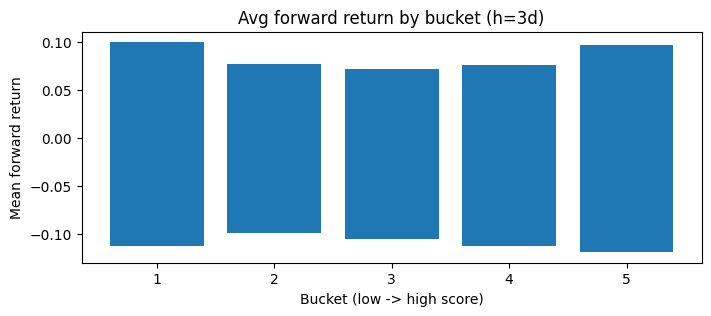

In [38]:
# Simple visualization: average forward return by bucket
plt.figure(figsize=(8,3))
plt.bar(bucket_df['bucket'].astype(str), bucket_df['avg_fwd_ret'])
plt.title(f'Avg forward return by bucket (h={horizon}d)')
plt.xlabel('Bucket (low -> high score)')
plt.ylabel('Mean forward return')
plt.show()

## 12) Execution-aware backtest (Top-K)

In [39]:
bt_daily, bt_summary = run_top_k_execution_backtest(
    scored_test,
    score_col='score',
    open_col='open',
    horizon_days=horizon,
    top_k=config.top_k,
    transaction_cost_bps=config.transaction_cost_bps,
    rebalance_every=1,
)

bt_daily['equity'] = (1 + bt_daily['net_ret']).cumprod()
pd.Series(bt_summary).sort_index()

annualized_return                                        0.190581
annualized_volatility                                    0.158522
avg_cost_drag                                            0.000865
avg_turnover                                             0.865416
backtest_method          open_to_open_tplus1_hold_3d_rebalance_1d
calmar                                                   0.927377
cumulative_return                                        0.294599
downside_volatility                                      0.122387
execution_mode                                       open_to_open
max_drawdown                                            -0.205505
profit_factor                                            1.238468
sharpe                                                   1.180293
sortino                                                  1.528779
win_rate                                                 0.549598
dtype: object

In [40]:
bt_daily.head()

,date,signal_date,exit_date,gross_ret,net_ret,turnover,cost_drag,equity
0,2024-06-28,2024-06-27,2024-07-03,0.003055,0.003055,0.0,0.0000,1.003055
1,2024-07-01,2024-06-28,2024-07-05,0.000980,0.000180,0.8,0.0008,1.003235
2,2024-07-02,2024-07-01,2024-07-08,0.006194,0.005794,0.4,0.0004,1.009048
3,2024-07-03,2024-07-02,2024-07-09,0.000973,0.000973,0.0,0.0000,1.010030
4,2024-07-05,2024-07-03,2024-07-10,0.000770,-0.000430,1.2,0.0012,1.009596


In [41]:
bt_daily.tail()

,date,signal_date,exit_date,gross_ret,net_ret,turnover,cost_drag,equity
368,2025-12-16,2025-12-15,2025-12-19,-0.003735,-0.004135,0.4,0.0004,1.294805
369,2025-12-17,2025-12-16,2025-12-22,0.003207,0.002407,0.8,0.0008,1.297922
370,2025-12-18,2025-12-17,2025-12-23,0.002747,0.001947,0.8,0.0008,1.300448
371,2025-12-19,2025-12-18,2025-12-24,-0.001920,-0.002720,0.8,0.0008,1.296912
372,2025-12-22,2025-12-19,2025-12-26,-0.000983,-0.001783,0.8,0.0008,1.294599


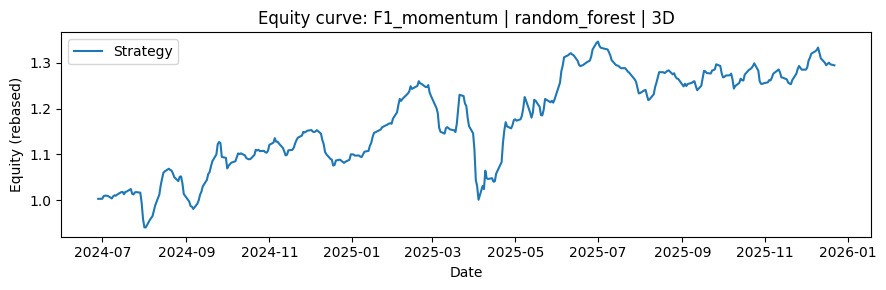

In [42]:
# Equity curve
plt.figure(figsize=(9,3))
plt.plot(bt_daily['date'], bt_daily['equity'], label='Strategy')
plt.title(f'Equity curve: {feature_set_name} | {model_name} | {horizon}D')
plt.xlabel('Date')
plt.ylabel('Equity (rebased)')
plt.legend()
plt.tight_layout()
plt.show()

## 13) Benchmark-relative summary vs SPY

In [43]:
bench_daily, bench_summary = run_benchmark_buy_hold(benchmark, horizon=horizon)
bench_daily['date'] = pd.to_datetime(bench_daily['date'])

# Align benchmark to strategy timeline so both curves share the same date range
bt_dates = pd.to_datetime(bt_daily['date'])
bench_daily = (
    bench_daily.set_index('date')
    .reindex(bt_dates)
    .rename_axis('date')
    .reset_index()
)
bench_daily['net_ret'] = bench_daily['net_ret'].fillna(0.0)
bench_daily['equity'] = (1 + bench_daily['net_ret']).cumprod()

rel = relative_summary(bt_daily, bench_daily)
pd.Series(rel).sort_index()

alpha_ann            0.025720
excess_ann_return   -0.002563
information_ratio    0.090515
dtype: float64

In [44]:
bt_daily

,date,signal_date,exit_date,gross_ret,net_ret,turnover,cost_drag,equity
0,2024-06-28,2024-06-27,2024-07-03,0.003055,0.003055,0.0,0.0000,1.003055
1,2024-07-01,2024-06-28,2024-07-05,0.000980,0.000180,0.8,0.0008,1.003235
2,2024-07-02,2024-07-01,2024-07-08,0.006194,0.005794,0.4,0.0004,1.009048
3,2024-07-03,2024-07-02,2024-07-09,0.000973,0.000973,0.0,0.0000,1.010030
4,2024-07-05,2024-07-03,2024-07-10,0.000770,-0.000430,1.2,0.0012,1.009596
...,...,...,...,...,...,...,...,...
368,2025-12-16,2025-12-15,2025-12-19,-0.003735,-0.004135,0.4,0.0004,1.294805
369,2025-12-17,2025-12-16,2025-12-22,0.003207,0.002407,0.8,0.0008,1.297922
370,2025-12-18,2025-12-17,2025-12-23,0.002747,0.001947,0.8,0.0008,1.300448
371,2025-12-19,2025-12-18,2025-12-24,-0.001920,-0.002720,0.8,0.0008,1.296912


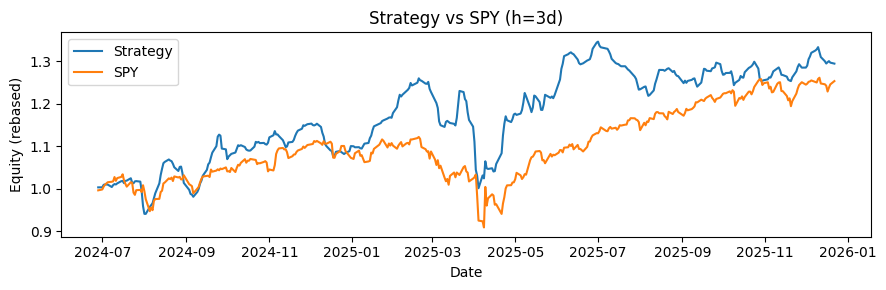

In [45]:
# Compare equity curves
plt.figure(figsize=(9,3))
plt.plot(bt_daily['date'], bt_daily['equity'], label='Strategy')
plt.plot(bench_daily['date'], bench_daily['equity'], label='SPY')
plt.title(f'Strategy vs SPY (h={horizon}d)')
plt.xlabel('Date')
plt.ylabel('Equity (rebased)')
plt.legend()
plt.tight_layout()
plt.show()

## 14) (Optional) Expand to multiple configs

Once the single-config pipeline is clear, you can loop across all feature sets/models/horizons and rebuild the same CSV outputs as `src.pipeline.run_pipeline`.

Tip: start with `config.horizons=[3]` and a smaller ticker list to keep runtime manageable.